## Aid Received Analysis

This notebook will explore and analyse the aid entering Gaza since the beginning of the genocide in Gaza. It will also look at whether the volume and composition of humanitarian aid is primarily constrained by border access rather than supply availability.

The aid_events mart is used for analysis, which is based on data from: https://data.humdata.org/dataset/state-of-palestine-gaza-aid-truck-data

Weekly aggregation is used to reduce daily volatility.

This page is currently still a work in progress.

### Hypothesis

Based on reports that aid trucks frequently queue at border crossings awaiting clearance, it is hypothesised that border access acts as a limiting factor for incoming aid.


Three specific hypotheses are tested:

- Total aid volume (measured in weekly pallet totals) increases during periods of ceasefire reletive to periods of active conflict.
- Food and water generally to be prioritised the most, followed by other important items such as: tents, bedding, medical items, hygiene items, clothes.
- Aid composition is skewed towards non-perishables during periods of reduced aid, due to trucks having to wait for long periods at the border.

In [19]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("../dev.duckdb")

In [20]:
x = con.execute("""
SELECT
    number_of_trucks,
    items,
    cargo_category,
    quantity,
    units,
    donation_type,
    crossing,
    organisation_name,
    organisation_role
FROM fct_aid_received f
JOIN bridge_organisation b
  ON f.aid_event_id = b.aid_event_id
JOIN dim_organisation o
  ON b.org_id = o.org_id
WHERE organisation_name = 'JICA'
""").df()

print(x)

   number_of_trucks             items    cargo_category  quantity    units  \
0                 1  Medical Supplies  Medical Supplies        42  Pallets   
1                 1  Medical Supplies  Medical Supplies        43  Pallets   
2                 1  Medical Supplies  Medical Supplies        41  Pallets   

       donation_type        crossing organisation_name organisation_role  
0  Humanitarian - UN  Rafah Crossing              JICA             donor  
1  Humanitarian - UN  Rafah Crossing              JICA             donor  
2  Humanitarian - UN  Rafah Crossing              JICA             donor  


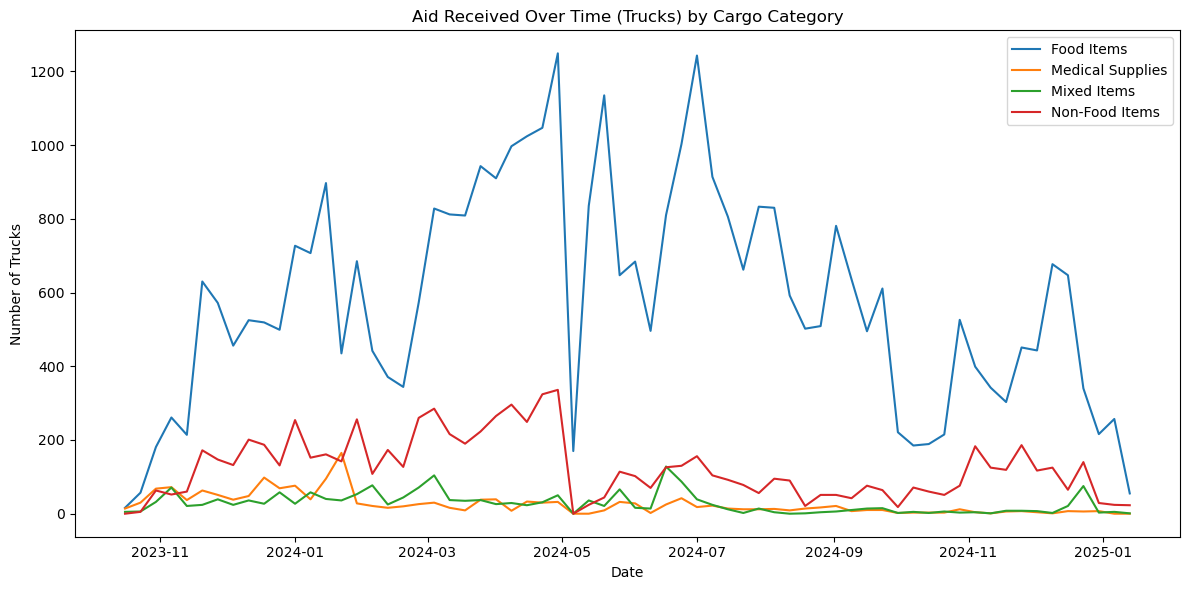

In [21]:
df = con.execute("""
SELECT
    year,
    week_of_year,
    cargo_category,
    SUM(number_of_trucks) AS sum_of_trucks
FROM main_mart.aid_events
GROUP BY year, week_of_year, cargo_category
ORDER BY year, week_of_year
""").df()

df["week_start"] = pd.to_datetime(
    df["year"].astype(str) + "-W" + df["week_of_year"].astype(str) + "-1",
    format="%G-W%V-%u"
)

df_pivot = df.pivot(
    index="week_start",
    columns="cargo_category",
    values="sum_of_trucks"
).fillna(0).sort_index()

plt.figure(figsize=(12,6))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], label=column)

plt.xlabel("Date")
plt.ylabel("Number of Trucks")
plt.title("Aid Received Over Time (Trucks) by Cargo Category")
plt.legend()
plt.tight_layout()
plt.show()


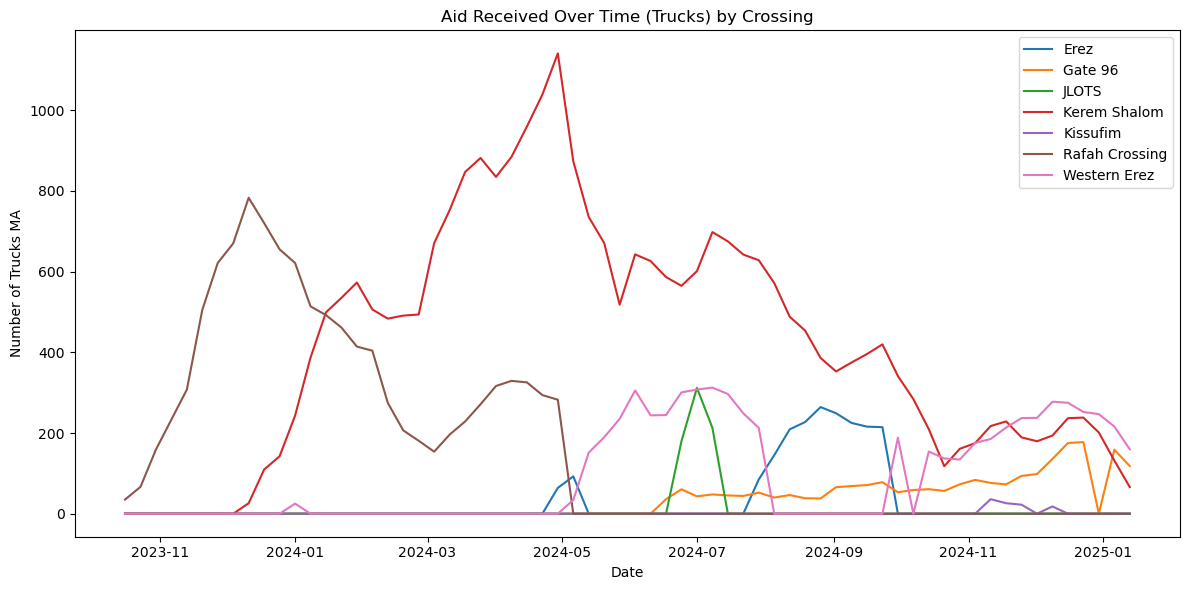

In [48]:
df = con.execute("""
SELECT
    crossing,
    SUM(number_of_trucks) AS sum_of_trucks,
    AVG(SUM(number_of_trucks)) OVER (PARTITION BY crossing ORDER BY year, week_of_year ASC ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS ma_3_day_trucks,    
    year,
    week_of_year
FROM main_mart.aid_events
GROUP BY crossing, year, week_of_year
ORDER BY year, week_of_year ASC
""").df()


df["week_start"] = pd.to_datetime(
    df["year"].astype(str) + "-W" + df["week_of_year"].astype(str) + "-1",
    format="%G-W%V-%u"
)

df_pivot = df.pivot(
    index="week_start",
    columns="crossing",
    values="ma_3_day_trucks"
).fillna(0).sort_index()

plt.figure(figsize=(12,6))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], label=column)

plt.xlabel("Date")
plt.ylabel("Number of Trucks MA")
plt.title("Aid Received Over Time (Trucks) by Crossing")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
con.execute("""
SELECT DISTINCT crossing, COUNT(crossing), SUM(number_of_trucks)
FROM main_mart.aid_events
GROUP BY crossing
ORDER BY COUNT(crossing) DESC
""").df()

,crossing,count(crossing),sum(number_of_trucks)
0,Kerem Shalom,27498,27498.0
1,Rafah Crossing,11080,11080.0
2,Western Erez,6304,6304.0
3,Gate 96,2297,2297.0
4,Erez,2170,2170.0
5,JLOTS,638,638.0
6,Kissufim,72,72.0


In [24]:
con.execute("""
SELECT DISTINCT units, COUNT(units)
FROM main_mart.aid_events
GROUP BY units
ORDER BY COUNT(units) DESC
""").df()

,units,count(units)
0,Pallets,38033
1,MT,6724
2,Truck,3610
3,Ton,364
4,Piece,168
5,Vehicles,10
6,Tents,6
7,CTN,3
8,EACH,3
9,Box,1


In [25]:
con.execute("""
SELECT DISTINCT items, cargo_category, SUM(number_of_trucks)
FROM main_mart.aid_events
GROUP BY 1, 2
ORDER BY 3 DESC
LIMIT 50
""").df()

,items,cargo_category,sum(number_of_trucks)
0,Flour,Food Items,11176.0
1,Food Parcels,Food Items,8710.0
2,Food Items,Food Items,2778.0
3,Water,Food Items,1597.0
4,Mattresses,Non-Food Items,1387.0
5,Blankets,Non-Food Items,1129.0
6,Medical Supplies,Medical Supplies,1101.0
7,Fruits,Food Items,1090.0
8,Hygiene Kits,Non-Food Items,1036.0
9,Mixed Food Items,Food Items,899.0
